# Local Video Inference Notebook v2 (Debug + Face Crop + Grayscale)

This notebook loads a trained PyTorch image classifier (`.pth`) and a local `model_metadata.json`,
reads a local video, extracts frames at a fixed interval, optionally applies **face detection + face crop**,
optionally applies **grayscale-to-3-channel preprocessing**, runs inference on each frame,
and outputs:

- `time_points`
- `drowsy_probability_sequence`
- `prob_drowsy`
- `prob_natural`
- debug information about face detection and crop usage

This version is designed to help diagnose domain-shift problems between your training images and your real video.


## 1. Install dependencies

Run the next cell only if these packages are not already installed in your local environment.

In [120]:
# !pip install torch torchvision opencv-python pillow matplotlib numpy pandas


## 2. Imports

In [121]:
import os
import json
from typing import List, Dict, Any, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models


## 3. Local path configuration and debug settings

In [122]:
# Edit these paths for your local machine
MODEL_PATH = 'best_resnet18_drowsy_classifier.pth'
METADATA_PATH = 'model_metadata.json'
VIDEO_PATH = 'test_video/test_video_4.mp4'

# Output folder for exports
OUTPUT_DIR = 'video_inference_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Inference settings
FRAME_INTERVAL_SEC = 0.5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Debug toggles
USE_FACE_CROP = True
FALLBACK_TO_FULL_FRAME = True   # if no face is detected
USE_GRAYSCALE_3CH = True       # turn on to test grayscale style closer to training images
FALLBACK_TO_PREVIOUS_BBOX = True

# Face crop box expansion ratios
# Because the mouth region matters for yawning, we expand more downward than upward.
EXPAND_LEFT = 0.18
EXPAND_RIGHT = 0.18
EXPAND_TOP = 0.10
EXPAND_BOTTOM = 0.28

# Haar detector settings
FACE_SCALE_FACTOR = 1.05
FACE_MIN_NEIGHBORS = 4
FACE_MIN_SIZE = (40, 40)

print("MODEL_PATH:", MODEL_PATH)
print("METADATA_PATH:", METADATA_PATH)
print("VIDEO_PATH:", VIDEO_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)
print("MODEL exists:", os.path.exists(MODEL_PATH))
print("METADATA exists:", os.path.exists(METADATA_PATH))
print("VIDEO exists:", os.path.exists(VIDEO_PATH))
print("USE_FACE_CROP:", USE_FACE_CROP)
print("USE_GRAYSCALE_3CH:", USE_GRAYSCALE_3CH)


MODEL_PATH: best_resnet18_drowsy_classifier.pth
METADATA_PATH: model_metadata.json
VIDEO_PATH: test_video/test_video_4.mp4
OUTPUT_DIR: video_inference_outputs
DEVICE: cuda
MODEL exists: True
METADATA exists: True
VIDEO exists: True
USE_FACE_CROP: True
USE_GRAYSCALE_3CH: True


## 4. Load metadata

In [123]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

metadata


{'model_name': 'resnet18',
 'num_classes': 2,
 'class_to_idx': {'DROWSY': 0, 'NATURAL': 1},
 'idx_to_class': {'0': 'DROWSY', '1': 'NATURAL'},
 'img_size': 224,
 'normalize_mean': [0.485, 0.456, 0.406],
 'normalize_std': [0.229, 0.224, 0.225],
 'task_type': 'binary_classification',
 'positive_class': 'DROWSY',
 'negative_class': 'NATURAL',
 'output_description': "Softmax over 2 classes. Use class_to_idx['DROWSY'] to extract drowsy probability.",
 'notes': 'This metadata must match the training-time model architecture and preprocessing.'}

## 5. Build model from metadata

In [124]:
def build_model_from_metadata(metadata: Dict[str, Any]) -> nn.Module:
    model_name = metadata["model_name"].lower()
    num_classes = metadata["num_classes"]

    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unsupported model_name: {metadata['model_name']}")

    return model

model = build_model_from_metadata(metadata)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

print(model.__class__.__name__)
print("Model loaded successfully.")


ResNet
Model loaded successfully.


## 6. Build inference transform and label mapping

In [125]:
img_size = metadata["img_size"]
normalize_mean = metadata["normalize_mean"]
normalize_std = metadata["normalize_std"]
class_to_idx = metadata["class_to_idx"]
idx_to_class = metadata["idx_to_class"]

drowsy_class_name = metadata.get("positive_class", "DROWSY")
natural_class_name = metadata.get("negative_class", "NATURAL")

drowsy_idx = class_to_idx[drowsy_class_name]
natural_idx = class_to_idx[natural_class_name]

inference_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

print("===== METADATA CHECK =====")
print("class_to_idx:", class_to_idx)
print("idx_to_class:", idx_to_class)
print("DROWSY index:", drowsy_idx)
print("NATURAL index:", natural_idx)
print("USE_GRAYSCALE_3CH:", USE_GRAYSCALE_3CH)


===== METADATA CHECK =====
class_to_idx: {'DROWSY': 0, 'NATURAL': 1}
idx_to_class: {'0': 'DROWSY', '1': 'NATURAL'}
DROWSY index: 0
NATURAL index: 1
USE_GRAYSCALE_3CH: True


## 7. Load face detector

In [126]:
# Try a slightly stronger frontal detector first
candidate_paths = [
    cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml",
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml",
]

face_cascade = None
face_cascade_path = None

for p in candidate_paths:
    detector = cv2.CascadeClassifier(p)
    if not detector.empty():
        face_cascade = detector
        face_cascade_path = p
        break

if face_cascade is None:
    raise RuntimeError("Failed to load OpenCV Haar cascade face detector.")

print("FACE_CASCADE_PATH:", face_cascade_path)
print("Face cascade loaded:", not face_cascade.empty())


FACE_CASCADE_PATH: d:\Miniconda\envs\ml\lib\site-packages\cv2\data\haarcascade_frontalface_alt2.xml
Face cascade loaded: True


## 8. Video helpers

In [127]:
def get_video_info(video_path: str) -> Dict[str, Any]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = frame_count / fps if fps > 0 else None
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {
        "fps": fps,
        "frame_count": frame_count,
        "duration_sec": duration_sec,
        "width": width,
        "height": height,
    }


def extract_frames_with_timestamps(video_path: str, frame_interval_sec: float = 0.5):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        raise ValueError("Invalid FPS detected from video.")

    frame_step = max(int(round(frame_interval_sec * fps)), 1)
    frames = []
    timestamps = []
    frame_idx = 0

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        if frame_idx % frame_step == 0:
            timestamp = frame_idx / fps
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            timestamps.append(round(timestamp, 3))

        frame_idx += 1

    cap.release()
    return timestamps, frames


## 9. Face detection, scoring, and crop helpers

In [128]:
def score_face_candidate(x: int, y: int, w: int, h: int, frame_shape: Tuple[int, int, int]) -> float:
    """
    Score a detected face candidate.
    Prefer larger and more central faces.
    """
    H, W = frame_shape[:2]
    area_score = (w * h) / float(W * H)

    cx = x + w / 2.0
    cy = y + h / 2.0
    center_x_dist = abs(cx - W / 2.0) / (W / 2.0)
    center_y_dist = abs(cy - H / 2.0) / (H / 2.0)
    center_penalty = 0.5 * center_x_dist + 0.5 * center_y_dist

    # larger is better, more central is better
    return area_score - 0.15 * center_penalty


def detect_faces(frame_rgb: np.ndarray):
    gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=FACE_SCALE_FACTOR,
        minNeighbors=FACE_MIN_NEIGHBORS,
        minSize=FACE_MIN_SIZE,
    )
    return faces


def select_best_face(faces, frame_rgb: np.ndarray):
    if len(faces) == 0:
        return None

    scored = []
    for (x, y, w, h) in faces:
        s = score_face_candidate(x, y, w, h, frame_rgb.shape)
        scored.append((s, (x, y, w, h)))

    scored = sorted(scored, key=lambda z: z[0], reverse=True)
    return scored[0][1]


def expand_bbox(x: int, y: int, w: int, h: int, frame_shape: Tuple[int, int, int]):
    H, W = frame_shape[:2]

    x1 = max(int(x - EXPAND_LEFT * w), 0)
    y1 = max(int(y - EXPAND_TOP * h), 0)
    x2 = min(int(x + w + EXPAND_RIGHT * w), W)
    y2 = min(int(y + h + EXPAND_BOTTOM * h), H)

    return x1, y1, x2, y2


def detect_and_crop_face(frame_rgb: np.ndarray):
    faces = detect_faces(frame_rgb)
    if len(faces) == 0:
        return None, None, []

    best_face = select_best_face(faces, frame_rgb)
    x, y, w, h = best_face
    x1, y1, x2, y2 = expand_bbox(x, y, w, h, frame_rgb.shape)
    cropped_face = frame_rgb[y1:y2, x1:x2]

    return cropped_face, (x1, y1, x2, y2), faces.tolist() if hasattr(faces, 'tolist') else list(faces)


In [129]:
def crop_with_bbox(frame_rgb: np.ndarray, bbox):
    """
    Crop an RGB frame using bbox = (x1, y1, x2, y2).
    Returns cropped image or None if bbox is invalid.
    """
    if bbox is None:
        return None

    x1, y1, x2, y2 = bbox
    H, W = frame_rgb.shape[:2]

    x1 = max(int(x1), 0)
    y1 = max(int(y1), 0)
    x2 = min(int(x2), W)
    y2 = min(int(y2), H)

    if x2 <= x1 or y2 <= y1:
        return None

    crop = frame_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        return None

    return crop

## 10. Preprocessing helper (optional grayscale-to-3ch)

In [130]:
def prepare_image_for_model(frame_rgb: np.ndarray, use_grayscale_3ch: bool = True) -> Image.Image:
    if use_grayscale_3ch:
        gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
        frame_rgb = np.stack([gray, gray, gray], axis=-1)
    return Image.fromarray(frame_rgb)


## 11. Face-detection preview on sampled frames

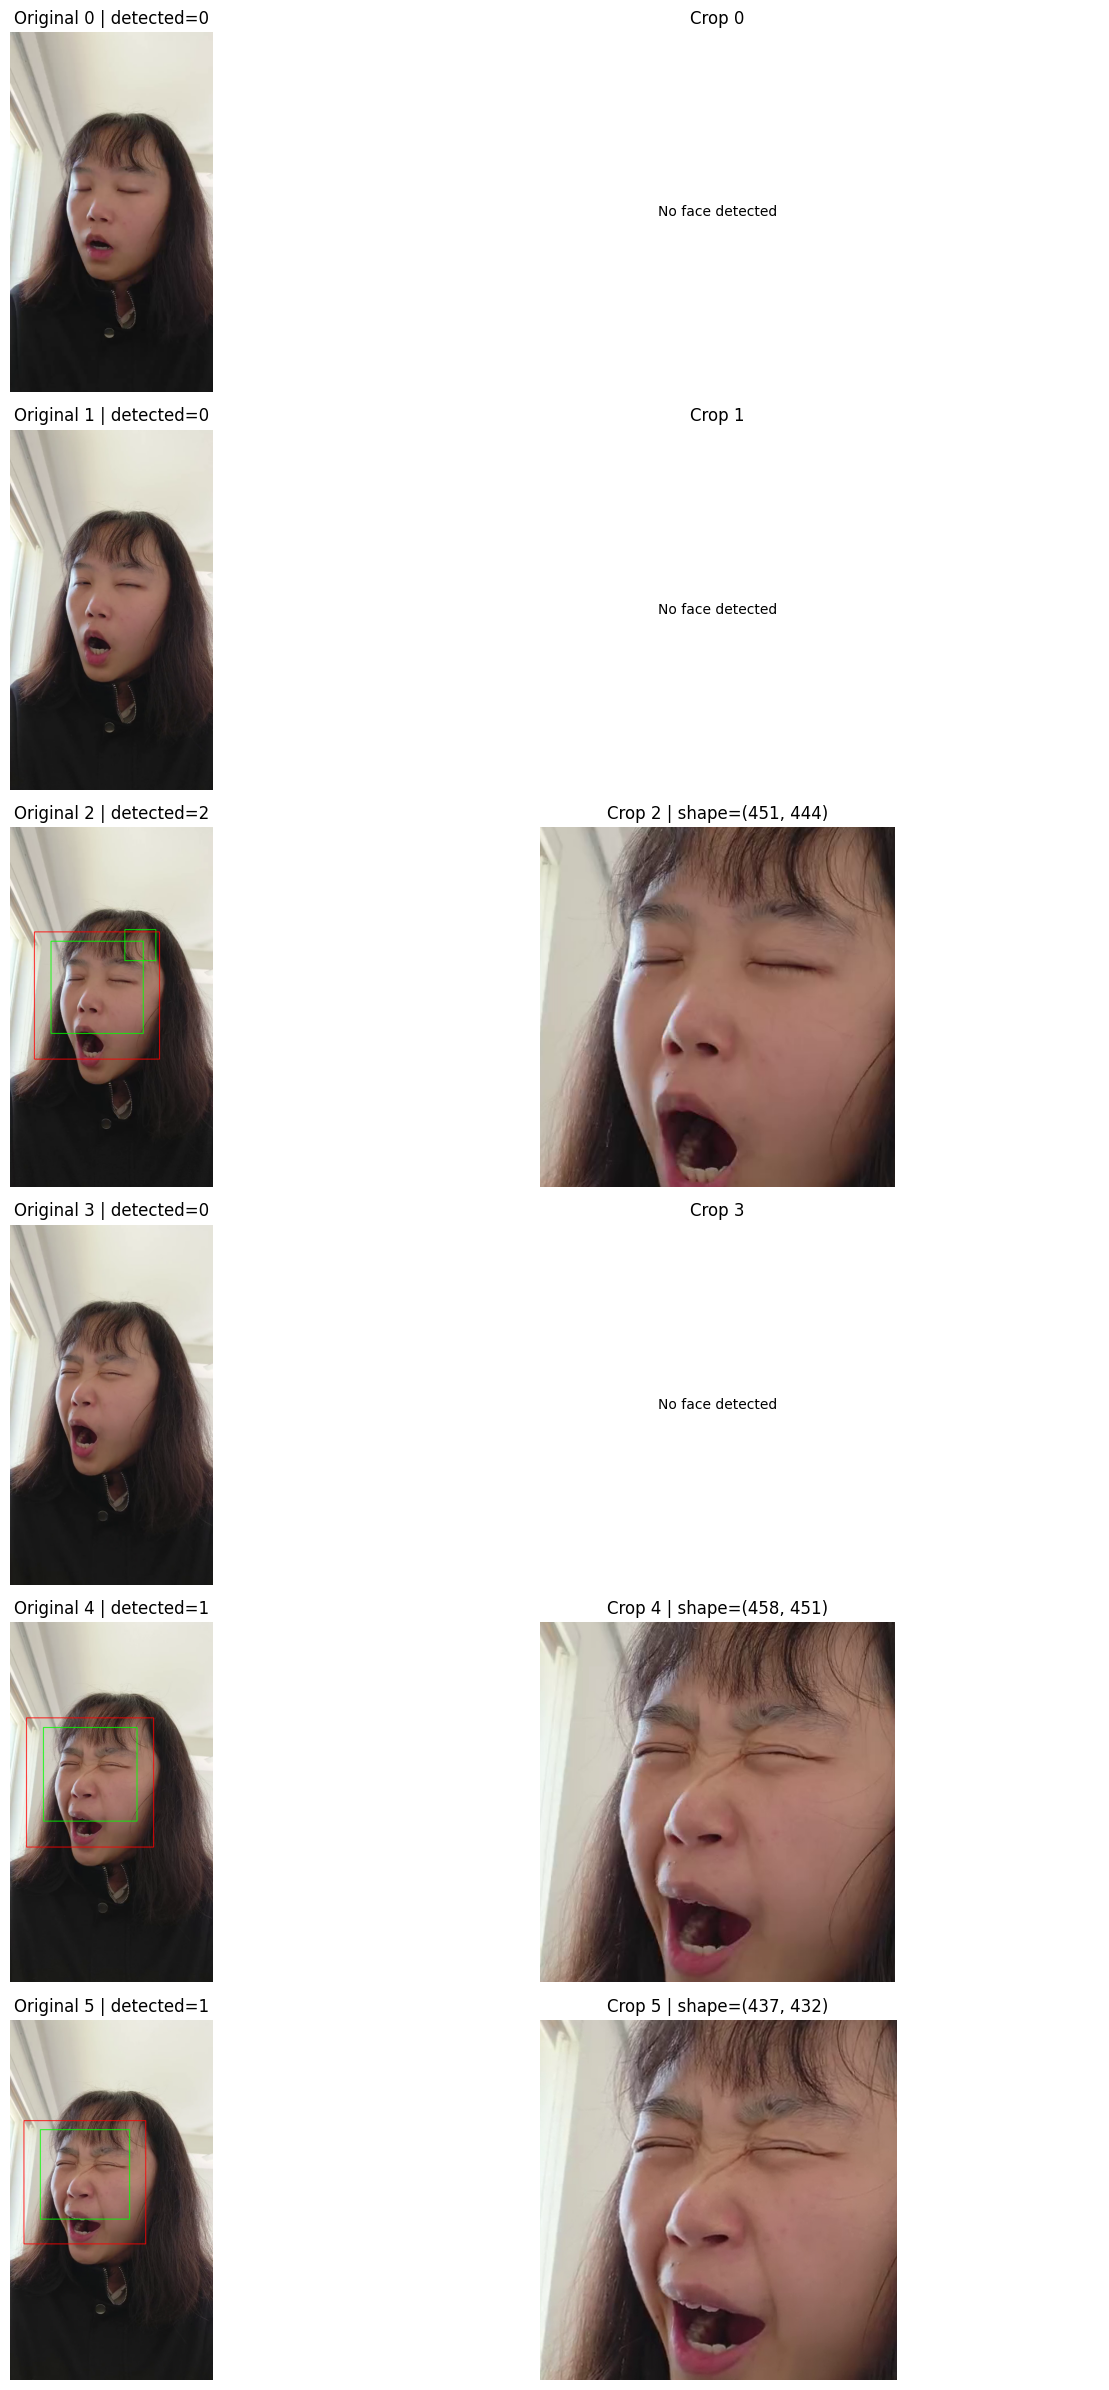

In [131]:
def show_face_detection_examples(frames: List[np.ndarray], num_show: int = 6):
    num_show = min(num_show, len(frames))
    plt.figure(figsize=(14, 4 * num_show))

    for i in range(num_show):
        frame = frames[i]
        cropped_face, bbox, all_faces = detect_and_crop_face(frame)

        plt.subplot(num_show, 2, 2 * i + 1)
        vis_img = frame.copy()
        for det in all_faces:
            x, y, w, h = det
            cv2.rectangle(vis_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        if bbox is not None:
            x1, y1, x2, y2 = bbox
            cv2.rectangle(vis_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        plt.imshow(vis_img)
        plt.title(f"Original {i} | detected={len(all_faces)}")
        plt.axis("off")

        plt.subplot(num_show, 2, 2 * i + 2)
        if cropped_face is not None:
            plt.imshow(cropped_face)
            plt.title(f"Crop {i} | shape={cropped_face.shape[:2]}")
        else:
            plt.text(0.5, 0.5, "No face detected", ha="center", va="center")
            plt.title(f"Crop {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


preview_time_points, preview_frames = extract_frames_with_timestamps(
    VIDEO_PATH,
    frame_interval_sec=FRAME_INTERVAL_SEC
)

show_face_detection_examples(preview_frames, num_show=6)


## 12. Single-image debug helper

Use this on one image or on manually cropped frames to compare full-frame vs face-crop behavior.

In [132]:
def get_pred_label_from_idx(pred_idx: int):
    if isinstance(list(idx_to_class.keys())[0], str):
        return idx_to_class[str(pred_idx)]
    return idx_to_class[pred_idx]


def debug_predict_pil_image(pil_image: Image.Image, title: str = "image"):
    tensor = inference_transform(pil_image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = get_pred_label_from_idx(pred_idx)

    print(f"===== DEBUG: {title} =====")
    print("raw probs:", probs)
    print(f"{drowsy_class_name} prob: {probs[drowsy_idx]:.6f}")
    print(f"{natural_class_name} prob: {probs[natural_idx]:.6f}")
    print("pred_idx:", pred_idx)
    print("pred_label:", pred_label)

    plt.figure(figsize=(4, 4))
    plt.imshow(pil_image)
    plt.title(f"{title}\nPred={pred_label}")
    plt.axis("off")
    plt.show()


def debug_compare_full_vs_crop(frame_rgb: np.ndarray, frame_name: str = "frame"):
    cropped_face, bbox, all_faces = detect_and_crop_face(frame_rgb)

    full_img = prepare_image_for_model(frame_rgb, use_grayscale_3ch=USE_GRAYSCALE_3CH)
    debug_predict_pil_image(full_img, title=f"{frame_name} | full frame")

    if cropped_face is not None:
        crop_img = prepare_image_for_model(cropped_face, use_grayscale_3ch=USE_GRAYSCALE_3CH)
        debug_predict_pil_image(crop_img, title=f"{frame_name} | face crop")
    else:
        print(f"No face detected for {frame_name}.")


## 13. Frame inference helper with face crop + grayscale options

In [133]:
def predict_frame_probability_debug(
    frame_rgb: np.ndarray,
    use_face_crop: bool = True,
    fallback_to_full_frame: bool = True,
    use_grayscale_3ch: bool = True,
):
    cropped_face, bbox, all_faces = detect_and_crop_face(frame_rgb)

    face_detected = cropped_face is not None
    used_face_crop = False

    if use_face_crop and face_detected:
        image_array = cropped_face
        used_face_crop = True
    else:
        if face_detected is False and fallback_to_full_frame:
            image_array = frame_rgb
        elif use_face_crop is False:
            image_array = frame_rgb
        else:
            return {
                "prob_drowsy": None,
                "prob_natural": None,
                "pred_label": None,
                "pred_idx": None,
                "all_probs": None,
                "face_detected": False,
                "used_face_crop": False,
                "bbox": None,
                "num_faces_detected": len(all_faces),
            }

    pil_image = prepare_image_for_model(image_array, use_grayscale_3ch=use_grayscale_3ch)
    tensor = inference_transform(pil_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = get_pred_label_from_idx(pred_idx)

    return {
        "prob_drowsy": float(probs[drowsy_idx]),
        "prob_natural": float(probs[natural_idx]),
        "pred_label": pred_label,
        "pred_idx": pred_idx,
        "all_probs": probs,
        "face_detected": face_detected,
        "used_face_crop": used_face_crop,
        "bbox": bbox,
        "num_faces_detected": len(all_faces),
    }


In [134]:
def predict_frame_probability_with_prev_bbox_fallback(
    frame_rgb: np.ndarray,
    previous_bbox=None,
    use_face_crop: bool = True,
    fallback_to_previous_bbox: bool = True,
    fallback_to_full_frame: bool = True,
    use_grayscale_3ch: bool = False,
):
    """
    Inference logic with three levels:
    1. Try current-frame face detection
    2. If no face is detected, try previous-frame bbox crop
    3. If still not available, optionally fall back to full frame
    """

    cropped_face, bbox, all_faces = detect_and_crop_face(frame_rgb)

    face_detected = cropped_face is not None
    used_face_crop = False
    used_prev_bbox_fallback = False

    if use_face_crop and face_detected:
        image_array = cropped_face
        used_face_crop = True
        final_bbox = bbox

    else:
        # Try previous bbox fallback
        if fallback_to_previous_bbox and previous_bbox is not None:
            prev_crop = crop_with_bbox(frame_rgb, previous_bbox)
            if prev_crop is not None:
                image_array = prev_crop
                used_prev_bbox_fallback = True
                final_bbox = previous_bbox
            else:
                final_bbox = None
                if fallback_to_full_frame:
                    image_array = frame_rgb
                else:
                    return {
                        "prob_drowsy": None,
                        "prob_natural": None,
                        "pred_label": None,
                        "pred_idx": None,
                        "all_probs": None,
                        "face_detected": False,
                        "used_face_crop": False,
                        "used_prev_bbox_fallback": False,
                        "used_full_frame_fallback": False,
                        "bbox": None,
                        "num_faces_detected": len(all_faces),
                    }

        else:
            final_bbox = None
            if fallback_to_full_frame:
                image_array = frame_rgb
            else:
                return {
                    "prob_drowsy": None,
                    "prob_natural": None,
                    "pred_label": None,
                    "pred_idx": None,
                    "all_probs": None,
                    "face_detected": False,
                    "used_face_crop": False,
                    "used_prev_bbox_fallback": False,
                    "used_full_frame_fallback": False,
                    "bbox": None,
                    "num_faces_detected": len(all_faces),
                }

    used_full_frame_fallback = (
        (not used_face_crop)
        and (not used_prev_bbox_fallback)
        and (not face_detected)
    )

    pil_image = prepare_image_for_model(
        image_array,
        use_grayscale_3ch=use_grayscale_3ch
    )
    tensor = inference_transform(pil_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = get_pred_label_from_idx(pred_idx)

    return {
        "prob_drowsy": float(probs[drowsy_idx]),
        "prob_natural": float(probs[natural_idx]),
        "pred_label": pred_label,
        "pred_idx": pred_idx,
        "all_probs": probs,
        "face_detected": face_detected,
        "used_face_crop": used_face_crop,
        "used_prev_bbox_fallback": used_prev_bbox_fallback,
        "used_full_frame_fallback": used_full_frame_fallback,
        "bbox": final_bbox,
        "num_faces_detected": len(all_faces),
    }

## 14. Quick compare: first few frames, full frame vs face crop

===== DEBUG: preview_frame_0 | full frame =====
raw probs: [0.21495731 0.78504264]
DROWSY prob: 0.214957
NATURAL prob: 0.785043
pred_idx: 1
pred_label: NATURAL


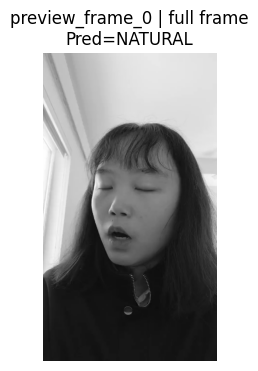

No face detected for preview_frame_0.
===== DEBUG: preview_frame_1 | full frame =====
raw probs: [0.42698395 0.57301605]
DROWSY prob: 0.426984
NATURAL prob: 0.573016
pred_idx: 1
pred_label: NATURAL


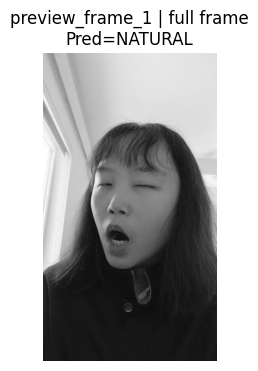

No face detected for preview_frame_1.


In [135]:
# Compare on one or two sampled frames if needed
if len(preview_frames) > 0:
    debug_compare_full_vs_crop(preview_frames[0], frame_name="preview_frame_0")
if len(preview_frames) > 1:
    debug_compare_full_vs_crop(preview_frames[1], frame_name="preview_frame_1")


## 15. Video-level inference with debug outputs

In [136]:
def predict_video_sequence_debug(
    video_path: str,
    frame_interval_sec: float = 0.5,
    use_face_crop: bool = True,
    fallback_to_previous_bbox: bool = True,
    fallback_to_full_frame: bool = True,
    use_grayscale_3ch: bool = False,
):
    time_points, frames = extract_frames_with_timestamps(
        video_path,
        frame_interval_sec=frame_interval_sec
    )

    results = []
    previous_bbox = None

    for t, frame in zip(time_points, frames):
        pred = predict_frame_probability_with_prev_bbox_fallback(
            frame,
            previous_bbox=previous_bbox,
            use_face_crop=use_face_crop,
            fallback_to_previous_bbox=fallback_to_previous_bbox,
            fallback_to_full_frame=fallback_to_full_frame,
            use_grayscale_3ch=use_grayscale_3ch,
        )

        # Update previous bbox only when current frame actually detects a face
        if pred["face_detected"] and pred["bbox"] is not None:
            previous_bbox = pred["bbox"]

        results.append({
            "time_sec": t,
            "prob_drowsy": pred["prob_drowsy"],
            "prob_natural": pred["prob_natural"],
            "pred_label": pred["pred_label"],
            "face_detected": pred["face_detected"],
            "used_face_crop": pred["used_face_crop"],
            "used_prev_bbox_fallback": pred["used_prev_bbox_fallback"],
            "used_full_frame_fallback": pred["used_full_frame_fallback"],
            "num_faces_detected": pred["num_faces_detected"],
            "bbox": pred["bbox"],
        })

    result_df = pd.DataFrame(results)
    return result_df, frames

## 16. Inspect video info

In [137]:
video_info = get_video_info(VIDEO_PATH)
video_info


{'fps': 30.00201355795691,
 'frame_count': 149,
 'duration_sec': 4.966333333333333,
 'width': 720,
 'height': 1280}

## 17. Run debug video inference

In [138]:
result_df, sampled_frames = predict_video_sequence_debug(
    VIDEO_PATH,
    frame_interval_sec=FRAME_INTERVAL_SEC,
    use_face_crop=USE_FACE_CROP,
    fallback_to_previous_bbox=FALLBACK_TO_PREVIOUS_BBOX,
    fallback_to_full_frame=FALLBACK_TO_FULL_FRAME,
    use_grayscale_3ch=USE_GRAYSCALE_3CH,
)

print("===== FALLBACK SUMMARY =====")
print("Total sampled frames:", len(result_df))
print("Face detected count:", int(result_df["face_detected"].sum()))
print("Used face crop count:", int(result_df["used_face_crop"].sum()))
print("Used previous bbox fallback count:", int(result_df["used_prev_bbox_fallback"].sum()))
print("Used full frame fallback count:", int(result_df["used_full_frame_fallback"].sum()))

if len(result_df) > 0:
    print("Face detection rate:", float(result_df["face_detected"].mean()))
    print("Prev-bbox fallback rate:", float(result_df["used_prev_bbox_fallback"].mean()))
    print("Full-frame fallback rate:", float(result_df["used_full_frame_fallback"].mean()))

===== FALLBACK SUMMARY =====
Total sampled frames: 10
Face detected count: 6
Used face crop count: 6
Used previous bbox fallback count: 2
Used full frame fallback count: 2
Face detection rate: 0.6
Prev-bbox fallback rate: 0.2
Full-frame fallback rate: 0.2


## 18. Plot drowsy probability sequence

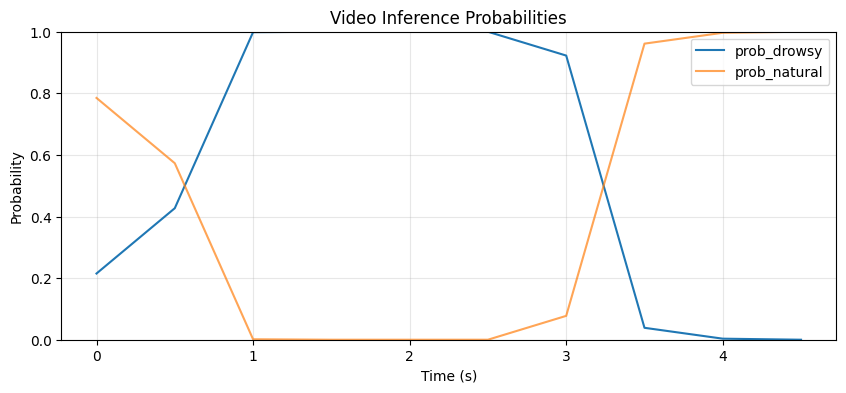

In [139]:
plt.figure(figsize=(10, 4))
plt.plot(result_df["time_sec"], result_df["prob_drowsy"], label="prob_drowsy")
plt.plot(result_df["time_sec"], result_df["prob_natural"], label="prob_natural", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Probability")
plt.title("Video Inference Probabilities")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 19. Preview sampled frames with debug annotations

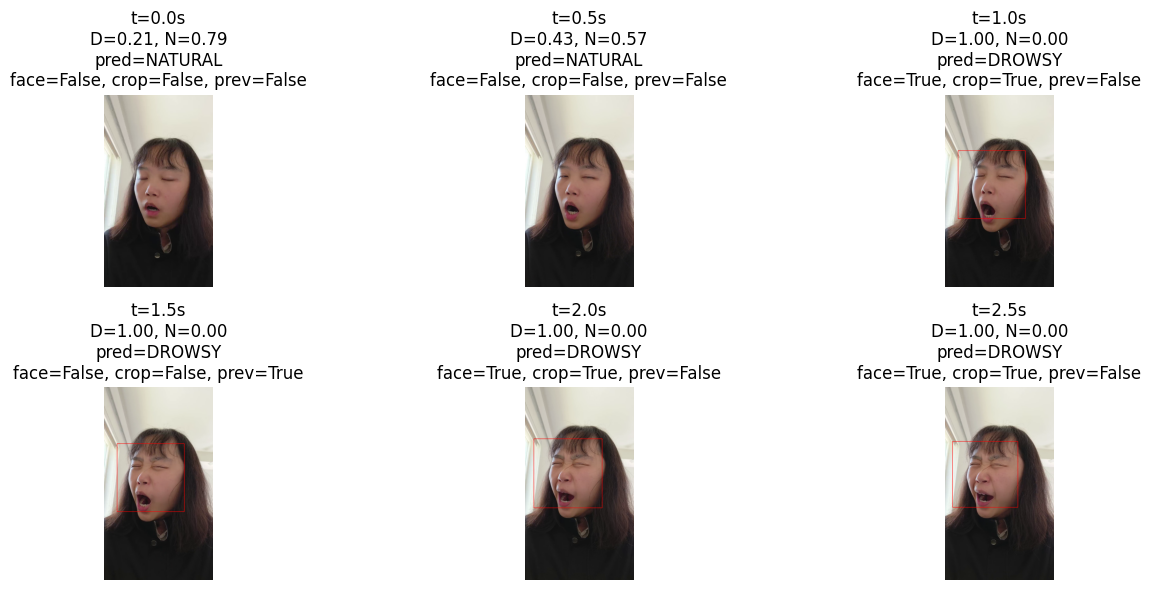

In [140]:
num_show = min(6, len(sampled_frames))
plt.figure(figsize=(15, 6))

for i in range(num_show):
    plt.subplot(2, 3, i + 1)
    frame = sampled_frames[i].copy()
    row = result_df.iloc[i]

    bbox = row["bbox"]
    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.imshow(frame)

    t = row["time_sec"]
    p_d = row["prob_drowsy"]
    p_n = row["prob_natural"]
    pred = row["pred_label"]
    face_detected = row["face_detected"]
    used_face_crop = row["used_face_crop"]
    used_prev_bbox_fallback = row["used_prev_bbox_fallback"]

    plt.title(
        f"t={t:.1f}s\n"
        f"D={p_d:.2f}, N={p_n:.2f}\n"
        f"pred={pred}\n"
        f"face={face_detected}, crop={used_face_crop}, prev={used_prev_bbox_fallback}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 20. Inspect actual cropped face images used for inference

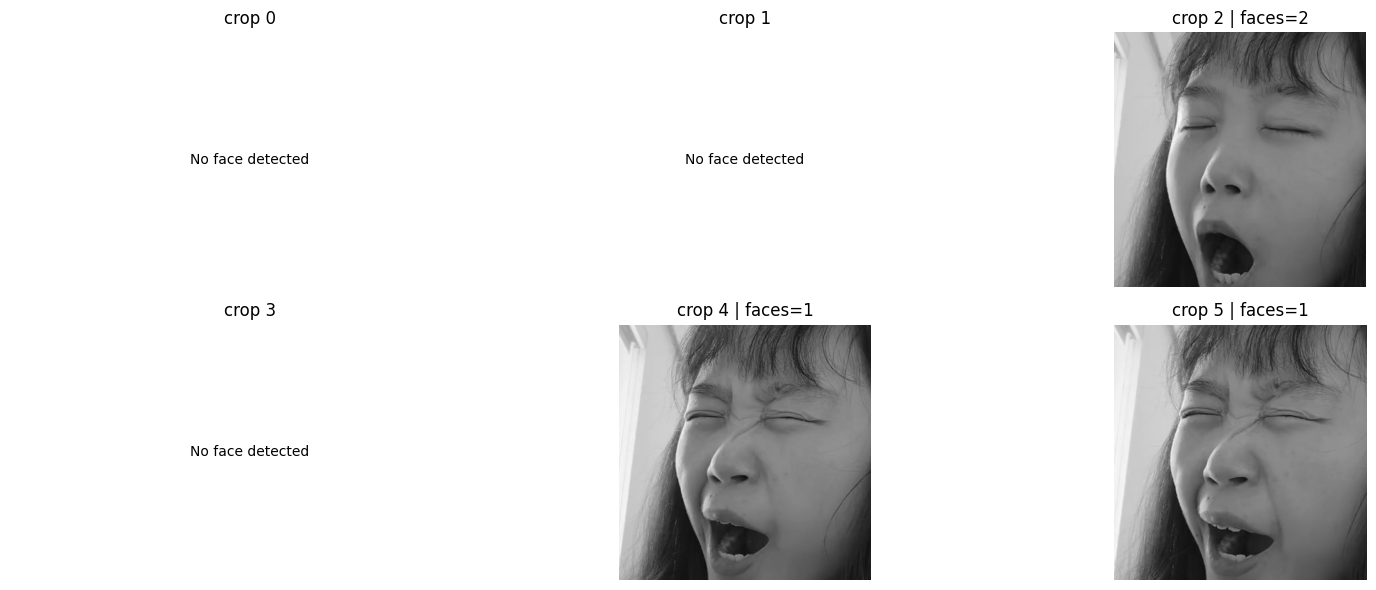

In [141]:
def show_actual_crops(frames: List[np.ndarray], num_show: int = 6):
    num_show = min(num_show, len(frames))
    plt.figure(figsize=(15, 6))

    for i in range(num_show):
        frame = frames[i]
        cropped_face, bbox, all_faces = detect_and_crop_face(frame)
        plt.subplot(2, 3, i + 1)
        if cropped_face is not None:
            show_img = cropped_face
            if USE_GRAYSCALE_3CH:
                gray = cv2.cvtColor(cropped_face, cv2.COLOR_RGB2GRAY)
                show_img = np.stack([gray, gray, gray], axis=-1)
            plt.imshow(show_img, cmap='gray' if USE_GRAYSCALE_3CH else None)
            plt.title(f"crop {i} | faces={len(all_faces)}")
        else:
            plt.text(0.5, 0.5, "No face detected", ha="center", va="center")
            plt.title(f"crop {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_actual_crops(sampled_frames, num_show=6)


## 21. Frame-by-frame text debug (first 10)

In [142]:
print("===== FRAME-BY-FRAME DEBUG (FIRST 10) =====")
for i in range(min(10, len(result_df))):
    row = result_df.iloc[i]
    print(
        f"t={row['time_sec']:.1f}s | "
        f"prob_drowsy={row['prob_drowsy']:.4f} | "
        f"prob_natural={row['prob_natural']:.4f} | "
        f"pred={row['pred_label']} | "
        f"face_detected={row['face_detected']} | "
        f"used_face_crop={row['used_face_crop']} | "
        f"bbox={row['bbox']}"
    )


===== FRAME-BY-FRAME DEBUG (FIRST 10) =====
t=0.0s | prob_drowsy=0.2150 | prob_natural=0.7850 | pred=NATURAL | face_detected=False | used_face_crop=False | bbox=None
t=0.5s | prob_drowsy=0.4270 | prob_natural=0.5730 | pred=NATURAL | face_detected=False | used_face_crop=False | bbox=None
t=1.0s | prob_drowsy=0.9986 | prob_natural=0.0014 | pred=DROWSY | face_detected=True | used_face_crop=True | bbox=(86, 375, 530, 826)
t=1.5s | prob_drowsy=1.0000 | prob_natural=0.0000 | pred=DROWSY | face_detected=False | used_face_crop=False | bbox=(86, 375, 530, 826)
t=2.0s | prob_drowsy=1.0000 | prob_natural=0.0000 | pred=DROWSY | face_detected=True | used_face_crop=True | bbox=(58, 343, 509, 801)
t=2.5s | prob_drowsy=1.0000 | prob_natural=0.0000 | pred=DROWSY | face_detected=True | used_face_crop=True | bbox=(49, 360, 481, 797)
t=3.0s | prob_drowsy=0.9225 | prob_natural=0.0775 | pred=DROWSY | face_detected=False | used_face_crop=False | bbox=(49, 360, 481, 797)
t=3.5s | prob_drowsy=0.0387 | prob_nat

## 22. Export outputs

In [143]:
csv_path = os.path.join(OUTPUT_DIR, "video_probability_sequence_debug.csv")
json_path = os.path.join(OUTPUT_DIR, "video_probability_sequence_debug.json")

result_df.to_csv(csv_path, index=False)

export_payload = {
    "video_path": VIDEO_PATH,
    "frame_interval_sec": FRAME_INTERVAL_SEC,
    "use_face_crop": USE_FACE_CROP,
    "use_grayscale_3ch": USE_GRAYSCALE_3CH,
    "time_points": result_df["time_sec"].tolist(),
    "drowsy_probability_sequence": result_df["prob_drowsy"].tolist(),
}

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export_payload, f, indent=2)

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)


Saved CSV: video_inference_outputs\video_probability_sequence_debug.csv
Saved JSON: video_inference_outputs\video_probability_sequence_debug.json


## 23. Ready-to-plug variables

In [144]:
time_points = result_df["time_sec"].tolist()
drowsy_probability_sequence = result_df["prob_drowsy"].tolist()

print("time_points[:5] =", time_points[:5])
print("drowsy_probability_sequence[:5] =", drowsy_probability_sequence[:5])


time_points[:5] = [0.0, 0.5, 1.0, 1.5, 2.0]
drowsy_probability_sequence[:5] = [0.2149573117494583, 0.42698395252227783, 0.9985575079917908, 0.9999687671661377, 0.9999973773956299]
